# Your First ML Model: Linear Regression Three Ways

**This notebook is self-contained; it recaps least squares and gradient descent before combining them.**

This is where the unit's two threads meet. `U3-7_GradientDescent-1_Descent` built an optimizer that
walks downhill on any function. `U3-7_Regression-1_FittingALine` defined a function worth minimizing, the sum of squared errors. Point one at the
other and you have **fitted a model to data by machine**.

We solve the same problem three ways, gradient descent, linear algebra, and a library call, get the
same answer from all three, and then name what we just did in the vocabulary the rest of your data
science coursework uses.

## Learning objectives

- Fit a line by **gradient descent** on the squared-error loss.
- Fit the same line by solving the **normal equations** directly.
- Fit it again with **scikit-learn**, and confirm all three agree.
- Use the vocabulary: **features, labels, parameters, loss, training, train/test split**.

## Background

The **loss** is a function of the two parameters we are choosing:

$$L(b_0, b_1) = \sum_i \left(y_i - (b_0 + b_1 x_i)\right)^2$$

Every pair $(b_0, b_1)$ gives a number, so $L$ is a **surface** over the parameter plane (§3.6), and
fitting the model means finding its lowest point. Happily it is a smooth bowl with exactly one
minimum, so the local-minimum trap of `U3-7_GradientDescent-1_Descent` cannot bite.

Three roads to that minimum:

1. **Gradient descent**, walk downhill using the partial derivatives
   $\frac{\partial L}{\partial b_0} = -2\sum(y_i - \hat{y}_i)$ and
   $\frac{\partial L}{\partial b_1} = -2\sum x_i(y_i - \hat{y}_i)$.
2. **Solve directly**, set both partials to zero, giving two linear equations in two unknowns (the
   **normal equations**), and solve them the way Unit 2 solved any linear system.
3. **Call a library**, `sklearn.linear_model.LinearRegression`, which does road 2 internally.

## This notebook covers

1. The data and the loss surface.
2. Road 1: gradient descent, with its path drawn on the surface.
3. Road 2: the normal equations.
4. Road 3: scikit-learn.
5. The ML vocabulary, and the train/test split.

**Prerequisites:** `U3-7_Regression-1_FittingALine`, `U3-7_GradientDescent-1_Descent`

**Dataset:** synthetic data with a known true line, so the recovered answer can be checked.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

from mpl_toolkits.mplot3d import Axes3D     # noqa: F401
np.random.seed(0)                            # reproducible data and numbers

## 1. The data and the loss surface

Generate points from a known line, $y = 1 + 2x$, with noise added. Because we *chose* the true
parameters, we can check whether each method recovers them.

In [2]:
n_pts = 100
true_intercept, true_slope, noise = 1.0, 2.0, 0.3

x = np.linspace(-1, 1, n_pts)
y = true_intercept + true_slope*x + np.random.normal(0, noise, n_pts)

def predict(x, params):
    return params[0] + params[1]*x

def loss(params):
    return np.sum((y - predict(x, params))**2)

print(f"{n_pts} points generated from  y = {true_intercept} + {true_slope}x  + noise")
print(f"loss at the true parameters      : {loss([true_intercept, true_slope]):.4f}")
print(f"loss at a bad guess [-3, -3]     : {loss([-3, -3]):.4f}")

100 points generated from  y = 1.0 + 2.0x  + noise
loss at the true parameters      : 9.1746
loss at a bad guess [-3, -3]     : 2458.5302


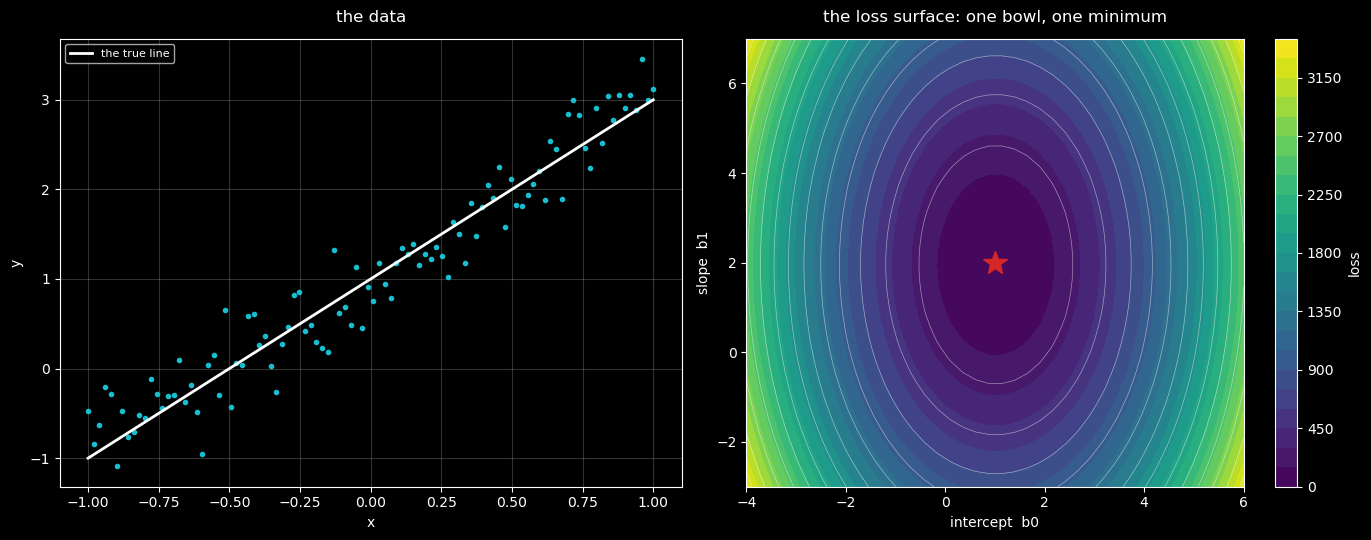

In [3]:
# the loss surface over the parameter plane
rad = 5
B0 = np.linspace(true_intercept - rad, true_intercept + rad, 40)
B1 = np.linspace(true_slope - rad, true_slope + rad, 40)
BB0, BB1 = np.meshgrid(B0, B1)
L = np.array([[loss([i, s]) for i in B0] for s in B1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].plot(x, y, ".", color="tab:cyan", markersize=6)
axes[0].plot(x, true_intercept + true_slope*x, color="white", lw=2, label="the true line")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.2)
axes[0].set_title("the data", pad=12)

cs = axes[1].contourf(BB0, BB1, L, levels=30, cmap="viridis")
axes[1].contour(BB0, BB1, L, levels=15, colors="white", linewidths=0.5, alpha=0.5)
fig.colorbar(cs, ax=axes[1], label="loss")
axes[1].plot(true_intercept, true_slope, "*", color="tab:red", markersize=18)
axes[1].set_xlabel("intercept  b0"); axes[1].set_ylabel("slope  b1")
axes[1].set_title("the loss surface: one bowl, one minimum", pad=12)
plt.tight_layout()
plt.show()

## 2. Road 1: gradient descent

The loss has two parameters, so the gradient has two components. Differentiating
$L = \sum(y_i - b_0 - b_1x_i)^2$ with respect to each (chain rule, §3.3):

$$\frac{\partial L}{\partial b_0} = -2\sum_i (y_i - \hat{y}_i), \qquad
  \frac{\partial L}{\partial b_1} = -2\sum_i x_i(y_i - \hat{y}_i)$$

Then the update rule from `U3-7_GradientDescent-1_Descent`, applied to both at once.

In [4]:
def gradient_descent(x, y, start, n_steps, lr):
    params = np.zeros((n_steps, 2))
    params[0] = start
    losses = np.zeros(n_steps)
    losses[0] = loss(start)
    for i in range(n_steps - 1):
        pred = predict(x, params[i])
        resid = y - pred
        grad = np.array([-2*np.sum(resid), -2*np.sum(x*resid)])
        params[i+1] = params[i] - lr*grad
        losses[i+1] = loss(params[i+1])
    return params, losses

path, losses = gradient_descent(x, y, start=[-3.0, -3.0], n_steps=500, lr=0.001)
gd_answer = path[-1]

print(f"started at  intercept {path[0,0]:+.4f}, slope {path[0,1]:+.4f},  loss {losses[0]:.2f}")
print(f"ended at    intercept {gd_answer[0]:+.4f}, slope {gd_answer[1]:+.4f},  loss {losses[-1]:.4f}")
print(f"true values intercept {true_intercept:+.4f}, slope {true_slope:+.4f}")

started at  intercept -3.0000, slope -3.0000,  loss 2458.53
ended at    intercept +1.0179, slope +1.9554,  loss 9.0748
true values intercept +1.0000, slope +2.0000


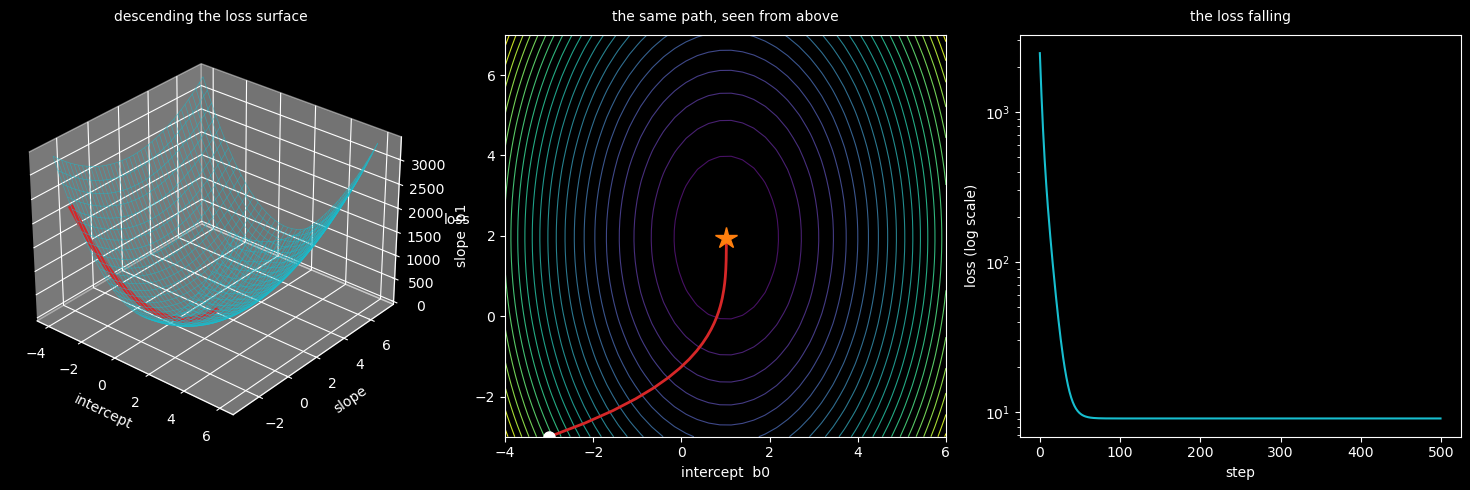

In [5]:
fig = plt.figure(figsize=(15, 5))

ax = fig.add_subplot(1, 3, 1, projection="3d")
ax.plot_wireframe(BB0, BB1, L, linewidth=0.5, color="tab:cyan", alpha=0.6)
ax.plot(path[:, 0], path[:, 1], [loss(p) for p in path], color="tab:red", lw=4)
ax.view_init(elev=30, azim=-50)
ax.set_xlabel("intercept"); ax.set_ylabel("slope"); ax.set_zlabel("loss")
ax.set_title("descending the loss surface", pad=10, fontsize=10)

ax = fig.add_subplot(1, 3, 2)
ax.contour(BB0, BB1, L, levels=25, cmap="viridis", linewidths=0.8)
ax.plot(path[:, 0], path[:, 1], color="tab:red", lw=2)
ax.plot(path[0, 0], path[0, 1], "o", color="white", markersize=8)
ax.plot(*gd_answer, "*", color="tab:orange", markersize=16)
ax.set_xlabel("intercept  b0"); ax.set_ylabel("slope  b1")
ax.set_title("the same path, seen from above", pad=10, fontsize=10)

ax = fig.add_subplot(1, 3, 3)
ax.semilogy(losses, color="tab:cyan")
ax.set_xlabel("step"); ax.set_ylabel("loss (log scale)")
ax.set_title("the loss falling", pad=10, fontsize=10)

plt.tight_layout()
plt.show()

The path runs **perpendicular to the contours**, exactly the property established in §3.6-3, now
doing real work. The right panel shows the loss dropping fast and then flattening: converged.

## 3. Road 2: solve it directly

Gradient descent *searched* for the minimum. But this particular loss is simple enough to **solve**.
Setting both partial derivatives to zero and rearranging gives two linear equations in $b_0$ and $b_1$:

$$\begin{aligned} n\,b_0 + \left(\sum x_i\right) b_1 &= \sum y_i\\ \left(\sum x_i\right) b_0 + \left(\sum x_i^2\right) b_1 &= \sum x_i y_i \end{aligned}$$

These are the **normal equations**, an ordinary linear system of the kind Unit 2 solved, so
`np.linalg.solve` finishes it in one line. (Where they come from, and how to write them for any number
of features, is the next notebook.)

In [6]:
coefficients = np.array([[n_pts,        np.sum(x)],
                         [np.sum(x),    np.sum(x*x)]])
rhs = np.array([np.sum(y), np.sum(x*y)])

helpers.show_aug(coefficients, rhs, label="the normal equations")

direct_answer = np.linalg.solve(coefficients, rhs)
print(f"intercept {direct_answer[0]:+.6f}")
print(f"slope     {direct_answer[1]:+.6f}")
print(f"\nloss at this answer: {loss(direct_answer):.6f}")
print(f"loss after gradient descent: {loss(gd_answer):.6f}")

<IPython.core.display.Math object>

intercept +1.017942
slope     +1.955401

loss at this answer: 9.074798
loss after gradient descent: 9.074798


## 4. Road 3: the library

In practice you would call a library, which does road 2 internally with more numerical care.
`scikit-learn` is the standard choice, and this is the first time in the unit we use it, deliberately,
because now you know exactly what it is doing.

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x.reshape(-1, 1), y)          # sklearn wants a 2-D array of features

print(f"intercept {model.intercept_:+.6f}")
print(f"slope     {model.coef_[0]:+.6f}")

intercept +1.017942
slope     +1.955401


In [8]:
print(f"{'method':<26} {'intercept':>12} {'slope':>12} {'loss':>12}")
print("-" * 66)
print(f"{'the true line':<26} {true_intercept:12.6f} {true_slope:12.6f} "
      f"{loss([true_intercept, true_slope]):12.4f}")
print(f"{'1. gradient descent':<26} {gd_answer[0]:12.6f} {gd_answer[1]:12.6f} {loss(gd_answer):12.4f}")
print(f"{'2. normal equations':<26} {direct_answer[0]:12.6f} {direct_answer[1]:12.6f} "
      f"{loss(direct_answer):12.4f}")
print(f"{'3. scikit-learn':<26} {model.intercept_:12.6f} {model.coef_[0]:12.6f} "
      f"{loss([model.intercept_, model.coef_[0]]):12.4f}")
print("-" * 66)
print("\nAll three land on the same line. Note the fitted line beats the TRUE line on loss --")
print("it is fitting this particular noise, which is exactly what section 5 is about.")

method                        intercept        slope         loss
------------------------------------------------------------------
the true line                  1.000000     2.000000       9.1746
1. gradient descent            1.017942     1.955401       9.0748
2. normal equations            1.017942     1.955401       9.0748
3. scikit-learn                1.017942     1.955401       9.0748
------------------------------------------------------------------

All three land on the same line. Note the fitted line beats the TRUE line on loss --
it is fitting this particular noise, which is exactly what section 5 is about.


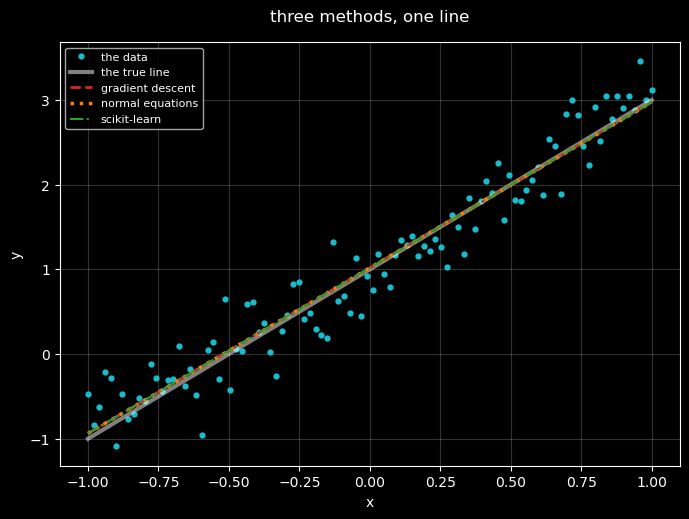

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(x, y, ".", color="tab:cyan", markersize=7, label="the data")
ax.plot(x, true_intercept + true_slope*x, color="white", lw=3, alpha=0.5, label="the true line")
ax.plot(x, predict(x, gd_answer), "--", color="tab:red", lw=2, label="gradient descent")
ax.plot(x, predict(x, direct_answer), ":", color="tab:orange", lw=2.5, label="normal equations")
ax.plot(x, model.predict(x.reshape(-1, 1)), "-.", color="tab:green", lw=1.5, label="scikit-learn")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.set_title("three methods, one line", pad=15)
plt.show()

## 5. What we just did, in ML vocabulary

**This is a machine-learning model**, the first in your program, and it is worth attaching the
standard names now, because every model in MSDS 550 and 565 uses them:

| Term | Here |
|---|---|
| **Feature** (input) | $x$, the variable we predict *from* |
| **Label** (target) | $y$, the variable we predict |
| **Model** | the straight line $\hat{y} = b_0 + b_1 x$ |
| **Parameters** | $b_0, b_1$, the numbers learned from data |
| **Loss** | the sum of squared errors, what "wrong" costs |
| **Training** | choosing the parameters that minimize the loss |
| **Prediction** | evaluating the model at a new $x$ |

The one habit that hasn't appeared yet: measuring performance on data the model **has not seen**. A
model is judged by how it handles new cases, not by how well it memorized the old ones, so we hold
some data back, **train** on the rest, and **test** on the held-out part.

In [10]:
from sklearn.model_selection import train_test_split

X = x.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print(f"{len(X_train)} points for training, {len(X_test)} held back for testing")

trained = LinearRegression().fit(X_train, y_train)
print(f"\nparameters learned from the training set only:")
print(f"   intercept {trained.intercept_:+.4f},  slope {trained.coef_[0]:+.4f}")

train_err = np.mean((trained.predict(X_train) - y_train)**2)
test_err = np.mean((trained.predict(X_test) - y_test)**2)
print(f"\nmean squared error on the training data : {train_err:.4f}")
print(f"mean squared error on the UNSEEN data   : {test_err:.4f}")
print("\nSimilar numbers mean the model generalizes. A test error much larger than the")
print("training error would mean it had memorized the training set -- overfitting, which")
print("is one of the first things MSDS 550 and 565 teach you to detect and prevent.")

70 points for training, 30 held back for testing

parameters learned from the training set only:
   intercept +0.9993,  slope +1.9927

mean squared error on the training data : 0.0874
mean squared error on the UNSEEN data   : 0.1014

Similar numbers mean the model generalizes. A test error much larger than the
training error would mean it had memorized the training set -- overfitting, which
is one of the first things MSDS 550 and 565 teach you to detect and prevent.


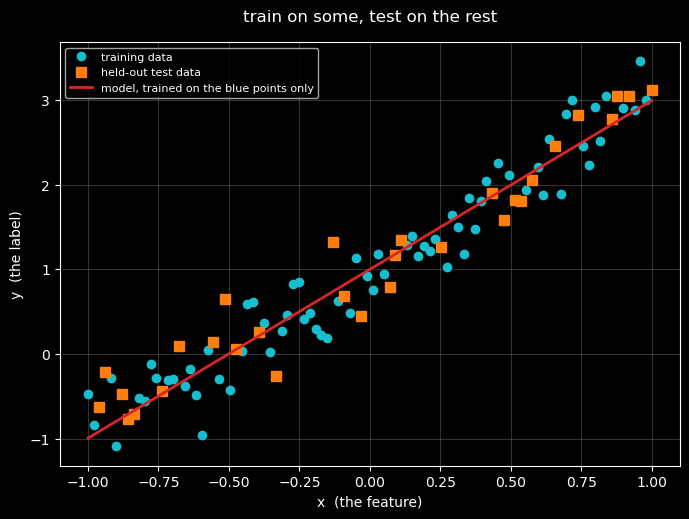

In [11]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(X_train.ravel(), y_train, "o", color="tab:cyan", markersize=6, label="training data")
ax.plot(X_test.ravel(), y_test, "s", color="tab:orange", markersize=7, label="held-out test data")
ax.plot(x, trained.predict(X), color="tab:red", lw=2, label="model, trained on the blue points only")
ax.set_xlabel("x  (the feature)"); ax.set_ylabel("y  (the label)")
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.set_title("train on some, test on the rest", pad=15)
plt.show()

## 6. Summary

- The **loss** $L(b_0, b_1)$ is a surface over the parameter plane; fitting a model is finding its minimum.
- **Gradient descent** searches for it, walking against the gradient: perpendicular to the loss
  contours, as §3.6-3 promised.
- The **normal equations** solve for it directly, as an ordinary linear system.
- **scikit-learn** does the same thing in two lines. All three agree.
- In ML vocabulary: $x$ is a **feature**, $y$ a **label**, $b_0, b_1$ are **parameters**, minimizing
  the loss is **training**, and performance is judged on a held-out **test set**.

You have now trained a machine-learning model, by hand and by library, and know exactly what happened
inside. Everything in MSDS 550 and 565 builds on this loop: define a model, define a loss, minimize it.

Next: where the normal equations come from, and how to write them for **any** number of features
(`U3-7_Regression-4_MatrixForm`).